In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from utils import automated_pipeline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [56]:
file_raw = r'E:\airta drafts\PREDIKSI KADAR HB\data\raw\erm_hd.xlsx'
df_raw = pd.read_excel(file_raw)

df = automated_pipeline(df_raw)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_pasien        639 non-null    int64         
 1   tgl_pemeriksaan  639 non-null    datetime64[ns]
 2   usia             639 non-null    Int64         
 3   jk               639 non-null    Int64         
 4   eritrosit        639 non-null    float64       
 5   hematokrit       639 non-null    float64       
 6   MCHC             639 non-null    float64       
 7   MCH              639 non-null    float64       
 8   MCV              639 non-null    float64       
 9   hemoglobin       639 non-null    float64       
 10  leukosit         639 non-null    Int64         
 11  trombosit        639 non-null    Int64         
 12  epo              639 non-null    Int64         
dtypes: Int64(5), datetime64[ns](1), float64(6), int64(1)
memory usage: 68.1 KB


In [57]:
df = df.sort_values(by=['id_pasien', 'tgl_pemeriksaan']).reset_index(drop=True)

#LAG FEATURE 
df['hb_lag'] = df.groupby('id_pasien')['hemoglobin'].shift(1)
df['hb_lag2'] = df.groupby('id_pasien')['hemoglobin'].shift(2)

df['hb_delta'] = df['hb_lag'] - df['hb_lag2']

df['inflamasi'] = (df['leukosit'] / 10000) * (df['trombosit'] / 150000)
df['epo_resist'] = df['epo'] / (df['inflamasi'] + 1)

lag_cols = ['hb_lag', 'hb_lag2']
df = df.dropna(subset=lag_cols).reset_index(drop=True)

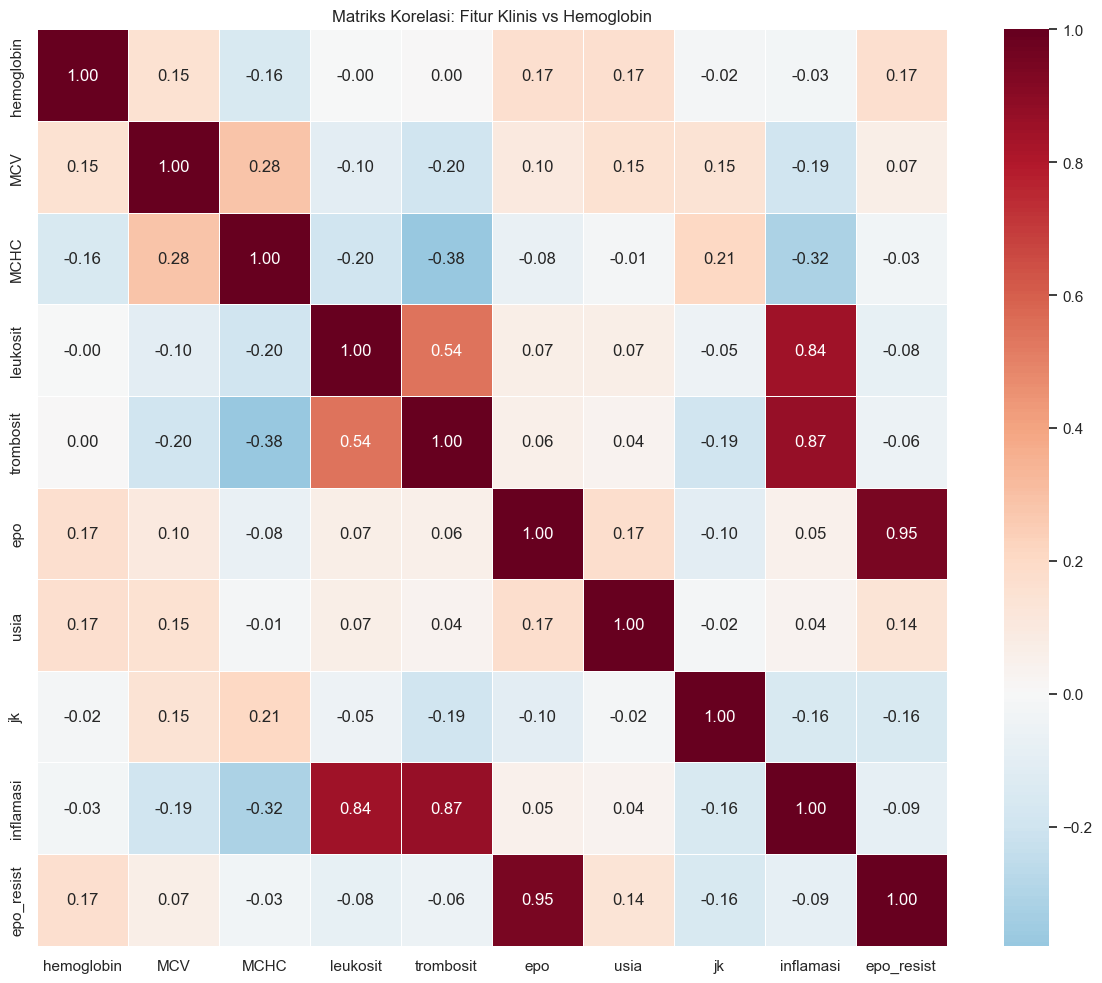

In [58]:
cols_to_corr = [
    'hemoglobin', 'MCV', 'MCHC', 'leukosit', 'trombosit',
    'epo', 'usia', 'jk', 'inflamasi', 'epo_resist'
]

corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title("Matriks Korelasi: Fitur Klinis vs Hemoglobin")
plt.tight_layout()
plt.show()

In [59]:
#MENENTUKAN FITUR X DAN TARGET Y
X = df.drop(columns=['id_pasien', 'tgl_pemeriksaan', 'hemoglobin', 'hematokrit', 'eritrosit', 'MCH', 'epo', 'inflamasi'])
y = df['hemoglobin']

#SPLIT 80:20 BERDASARKAN KRONOLOGIS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    shuffle=False
)

print(f"Total baris data: {len(df)}")
print(f"Jumlah Data Latih (80%): {len(X_train)}")
print(f"Jumlah Data Uji (20%): {len(X_test)}")
print("-" * 30)
print("Fitur yang digunakan (X):", X.columns.tolist())

Total baris data: 497
Jumlah Data Latih (80%): 397
Jumlah Data Uji (20%): 100
------------------------------
Fitur yang digunakan (X): ['usia', 'jk', 'MCHC', 'MCV', 'leukosit', 'trombosit', 'hb_lag', 'hb_lag2', 'hb_delta', 'epo_resist']


In [60]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print(f"Total baris di X_train: {len(X_train)}")
print("-" * 30)

for i, (train_index, val_index) in enumerate(tscv.split(X_train)):
    print(f"Iterasi ke-{i+1}:")
    print(f"  Jumlah Data Latih: {len(train_index)} baris (Indeks {train_index[0]} s/d {train_index[-1]})")
    print(f"  Jumlah Data Validasi: {len(val_index)} baris (Indeks {val_index[0]} s/d {val_index[-1]})")
    print("-" * 30)

Total baris di X_train: 397
------------------------------
Iterasi ke-1:
  Jumlah Data Latih: 67 baris (Indeks 0 s/d 66)
  Jumlah Data Validasi: 66 baris (Indeks 67 s/d 132)
------------------------------
Iterasi ke-2:
  Jumlah Data Latih: 133 baris (Indeks 0 s/d 132)
  Jumlah Data Validasi: 66 baris (Indeks 133 s/d 198)
------------------------------
Iterasi ke-3:
  Jumlah Data Latih: 199 baris (Indeks 0 s/d 198)
  Jumlah Data Validasi: 66 baris (Indeks 199 s/d 264)
------------------------------
Iterasi ke-4:
  Jumlah Data Latih: 265 baris (Indeks 0 s/d 264)
  Jumlah Data Validasi: 66 baris (Indeks 265 s/d 330)
------------------------------
Iterasi ke-5:
  Jumlah Data Latih: 331 baris (Indeks 0 s/d 330)
  Jumlah Data Validasi: 66 baris (Indeks 331 s/d 396)
------------------------------


In [61]:
df_check = df.copy()
df_check['set'] = 'train'
df_check.loc[X_test.index, 'set'] = 'test'

df_check[['id_pasien', 'tgl_pemeriksaan', 'hb_lag', 'hb_lag2', 'hemoglobin', 'set']].iloc[
    len(X_train)-5 : len(X_train)+5
]

,id_pasien,tgl_pemeriksaan,hb_lag,hb_lag2,hemoglobin,set
392,53,2025-10-01,9.3,8.6,8.6,train
393,53,2025-11-01,8.6,9.3,7.0,train
394,53,2025-12-01,7.0,8.6,8.6,train
395,53,2026-01-01,8.6,7.0,7.7,train
396,54,2025-05-01,7.3,8.4,7.6,train
397,54,2025-06-01,7.6,7.3,8.6,test
398,54,2025-07-01,8.6,7.6,9.5,test
399,54,2025-08-01,9.5,8.6,9.0,test
400,54,2025-09-01,9.0,9.5,8.2,test
401,54,2025-10-01,8.2,9.0,8.5,test


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

best_models = {}

# 1. GRID SEARCH SVR
print("Menjalankan Grid Search SVR...")
param_grid_svr = {
    'model__C': [0.1, 1, 10, 100],
    'model__epsilon': [0.01, 0.1, 0.5],
    'model__gamma': ['scale', 'auto', 0.01, 0.1]
}
pipe_svr = Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf'))])
grid_svr = GridSearchCV(pipe_svr, param_grid_svr, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_svr.fit(X_train, y_train)
latency_svr = time.time() - start_time
best_models['SVR'] = {'best_mae': -grid_svr.best_score_, 'params': grid_svr.best_params_, 'latency': latency_svr}

# 2. GRID SEARCH RANDOM FOREST
print("Menjalankan Grid Search Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5]
}
rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_rf.fit(X_train, y_train)
latency_rf = time.time() - start_time
best_models['RF'] = {'best_mae': -grid_rf.best_score_, 'params': grid_rf.best_params_, 'latency': latency_rf}

# 3. GRID SEARCH LIGHTGBM
print("Menjalankan Grid Search LightGBM...")
param_grid_lgbm = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [7, 15]
}
lgbm = LGBMRegressor(random_state=42, verbose=-1)
grid_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_lgbm.fit(X_train, y_train)
latency_lgbm = time.time() - start_time
best_models['LGBM'] = {'best_mae': -grid_lgbm.best_score_, 'params': grid_lgbm.best_params_, 'latency': latency_lgbm}

# 4. GRID SEARCH XGBOOST
print("Menjalankan Grid Search XGBoost...")
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
xgb = XGBRegressor(random_state=42, n_jobs=-1)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
start_time = time.time()
grid_xgb.fit(X_train, y_train)
latency_xgb = time.time() - start_time
best_models['XGB'] = {'best_mae': -grid_xgb.best_score_, 'params': grid_xgb.best_params_, 'latency': latency_xgb}

# --- RINGKASAN PARAMETER TERBAIK ---
print("\n=== RINGKASAN PARAMETER TERBAIK (GRID SEARCH) ===")
for model_name, info in best_models.items():
    print(f"\nModel: {model_name}")
    print(f"  > Best MAE: {info['best_mae']:.4f}")
    print(f"  > Parameters: {info['params']}")
    print(f"  > Latency Training: {info['latency']:.2f} detik")

Menjalankan Grid Search SVR...


Menjalankan Grid Search Random Forest...
Menjalankan Grid Search LightGBM...
Menjalankan Grid Search XGBoost...

=== RINGKASAN PARAMETER TERBAIK (GRID SEARCH) ===

Model: SVR
  > Best MAE: 0.6432
  > Parameters: {'model__C': 1, 'model__epsilon': 0.01, 'model__gamma': 0.01}
  > Latency Training: 16.23 detik

Model: RF
  > Best MAE: 0.6784
  > Parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
  > Latency Training: 8.06 detik

Model: LGBM
  > Best MAE: 0.6680
  > Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'num_leaves': 7}
  > Latency Training: 7.13 detik

Model: XGB
  > Best MAE: 0.7162
  > Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
  > Latency Training: 2.74 detik


In [63]:
df_hasil = pd.DataFrame(best_models).T
df_hasil = df_hasil.reset_index().rename(columns={'index': 'Algoritma'})
df_hasil = df_hasil.sort_values('best_mae')

print("HASIL PERBANDINGAN GRID SEARCH (TSCV)")
print("-" * 50)
print(df_hasil[['Algoritma', 'best_mae', 'latency']])

HASIL PERBANDINGAN GRID SEARCH (TSCV)
--------------------------------------------------
  Algoritma  best_mae    latency
0       SVR   0.64317  16.229143
2      LGBM  0.667954   7.131553
1        RF  0.678426    8.05832
3       XGB  0.716166   2.744293


In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time # Pastikan library time diimpor

models_final = {}

# Baseline
models_final["Linear Regression (Baseline)"] = LinearRegression()

# SVR
models_final["SVR"] = grid_svr.best_estimator_

# Tree-based Models
models_final["Random Forest"] = RandomForestRegressor(**grid_rf.best_params_, random_state=42)
models_final["LightGBM"] = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)
models_final["XGBoost"] = XGBRegressor(**grid_xgb.best_params_, random_state=42)

# Evaluasi pada X_test
final_results = []

for name, model in models_final.items():
    model.fit(X_train, y_train)
    
    # --- PROSES PENGUKURAN INFERENCE LATENCY ---
    start_inf = time.perf_counter() # Mulai hitung waktu sebelum prediksi
    y_pred = model.predict(X_test)
    end_inf = time.perf_counter()   # Selesai hitung waktu setelah prediksi
    
    inf_lat = end_inf - start_inf   # Hasil latency pengujian (Inference)
    # -------------------------------------------
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    final_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Inference Latency (s)": inf_lat # Menggunakan hasil perhitungan baru
    })

df_final = pd.DataFrame(final_results).sort_values(by="MAE")
print(df_final.to_string(index=False))

                       Model      MAE     RMSE       R2  Inference Latency (s)
                    LightGBM 0.657725 0.832047 0.434694               0.003060
               Random Forest 0.678952 0.851711 0.407658               0.020322
                         SVR 0.717368 0.881641 0.365297               0.013423
                     XGBoost 0.728615 0.893923 0.347489               0.004128
Linear Regression (Baseline) 0.729648 0.905066 0.331120               0.003537


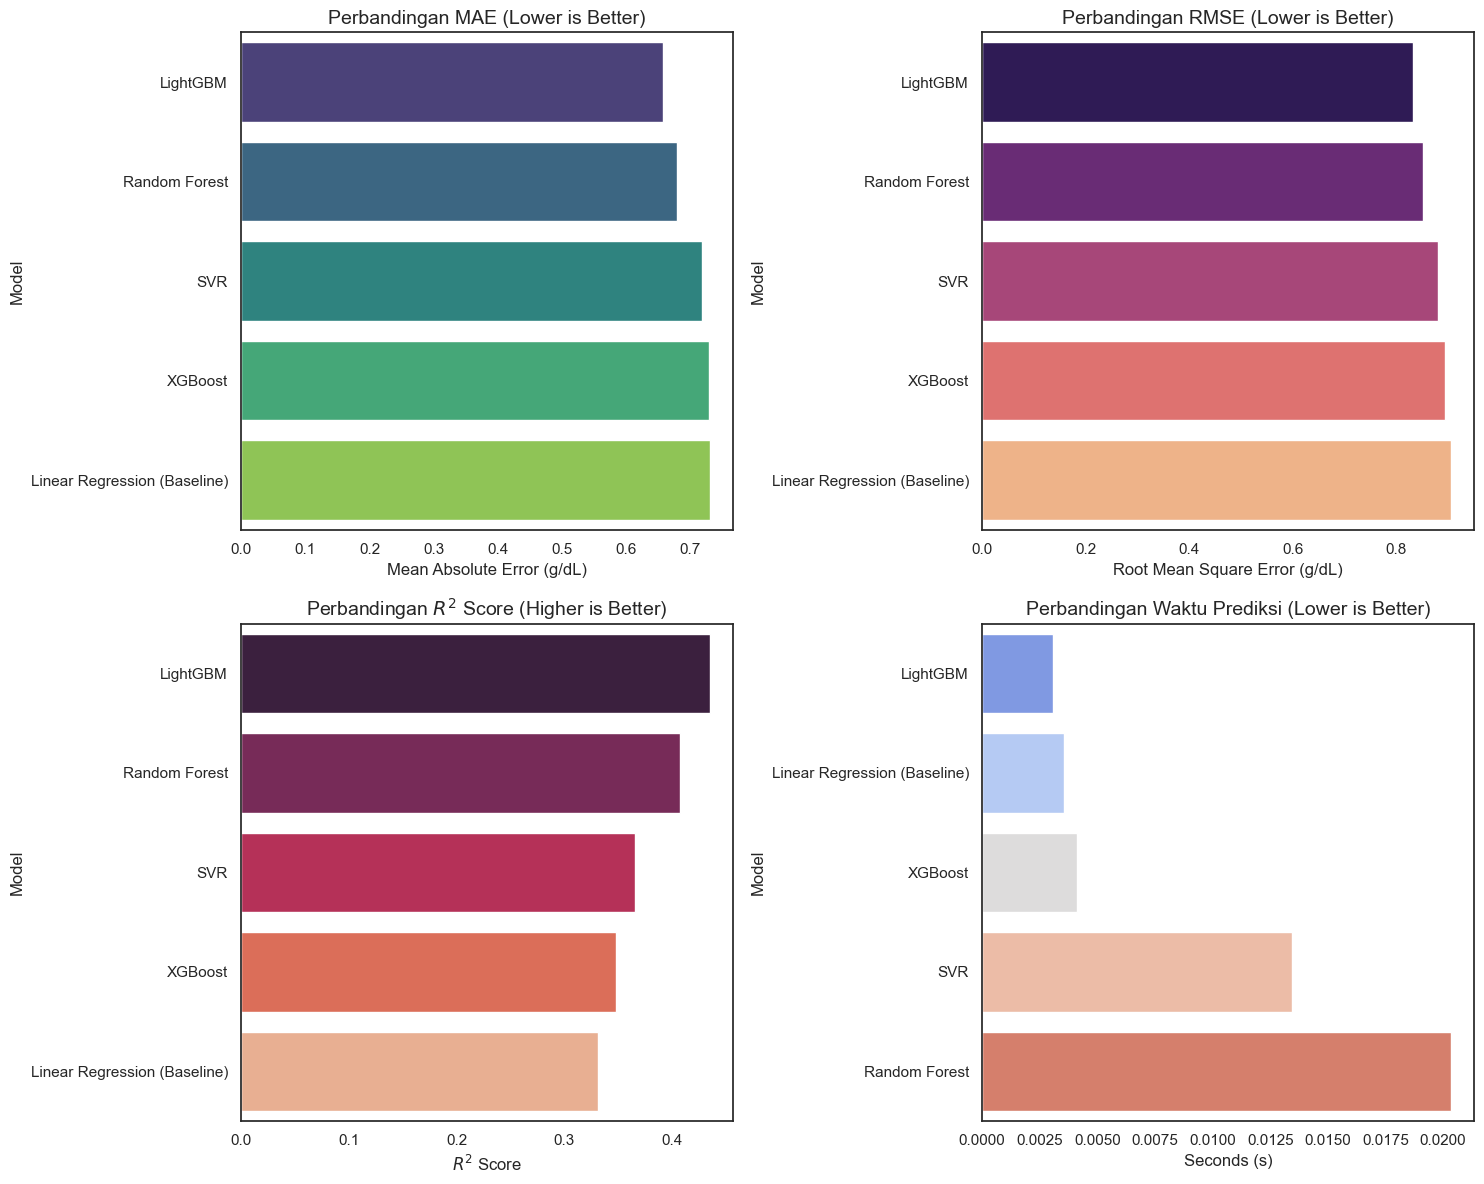

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Grafik MAE (Semakin rendah semakin baik)
sns.barplot(x='MAE', y='Model', data=df_final.sort_values('MAE'), ax=axes[0, 0], 
            palette='viridis', hue='Model', legend=False)
axes[0, 0].set_title('Perbandingan MAE (Lower is Better)', fontsize=14)
axes[0, 0].set_xlabel('Mean Absolute Error (g/dL)')

# 2. Grafik RMSE (Semakin rendah semakin baik)
sns.barplot(x='RMSE', y='Model', data=df_final.sort_values('RMSE'), ax=axes[0, 1], 
            palette='magma', hue='Model', legend=False)
axes[0, 1].set_title('Perbandingan RMSE (Lower is Better)', fontsize=14)
axes[0, 1].set_xlabel('Root Mean Square Error (g/dL)')

# 3. Grafik R2 Score (Semakin tinggi semakin baik)
sns.barplot(x='R2', y='Model', data=df_final.sort_values('R2', ascending=False), ax=axes[1, 0], 
            palette='rocket', hue='Model', legend=False)
axes[1, 0].set_title('Perbandingan $R^2$ Score (Higher is Better)', fontsize=14)
axes[1, 0].set_xlabel('$R^2$ Score')

# 4. Grafik Inference Latency (Kecepatan Prediksi)
sns.barplot(x='Inference Latency (s)', y='Model', data=df_final.sort_values('Inference Latency (s)'), ax=axes[1, 1], 
            palette='coolwarm', hue='Model', legend=False)
axes[1, 1].set_title('Perbandingan Waktu Prediksi (Lower is Better)', fontsize=14)
axes[1, 1].set_xlabel('Seconds (s)')

plt.tight_layout()
plt.show()

In [66]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models_final.items():
    
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error'
    )
    
    cv_mae = -cv_scores.mean()
    
    cv_results.append({
        "Model": name,
        "CV_MAE": cv_mae
    })

df_cv = pd.DataFrame(cv_results)
print(df_cv)


                          Model    CV_MAE
0  Linear Regression (Baseline)  0.652478
1                           SVR  0.643170
2                 Random Forest  0.678426
3                      LightGBM  0.667954
4                       XGBoost  0.716166


In [67]:
from sklearn.model_selection import cross_val_score
import pandas as pd

final_candidates = {
    "Linear Regression (Baseline)": LinearRegression(),
    "SVR": grid_svr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "LightGBM": grid_lgbm.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

cv_stability_results = {}

print("=== ANALISIS STABILITAS MAE PER FOLD (TSCV) ===")
print("-" * 50)

for name, model in final_candidates.items():
    # Hitung Cross Validation Score
    cv_scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_folds = -cv_scores
    
    cv_stability_results[name] = {
        'Fold 1': mae_folds[0],
        'Fold 2': mae_folds[1],
        'Fold 3': mae_folds[2],
        'Fold 4': mae_folds[3],
        'Fold 5': mae_folds[4],
        'Rata-rata': mae_folds.mean(),
        'Std Dev': mae_folds.std()
    }
    
    print(f"Selesai menghitung stabilitas untuk: {name}")

df_stabilitas = pd.DataFrame(cv_stability_results).T

df_stabilitas = df_stabilitas.sort_values(by='Rata-rata')

print("\nTABEL RINGKASAN STABILITAS MODEL:")
print("-" * 80)
print(df_stabilitas.to_string())

=== ANALISIS STABILITAS MAE PER FOLD (TSCV) ===
--------------------------------------------------
Selesai menghitung stabilitas untuk: Linear Regression (Baseline)
Selesai menghitung stabilitas untuk: SVR
Selesai menghitung stabilitas untuk: Random Forest
Selesai menghitung stabilitas untuk: LightGBM
Selesai menghitung stabilitas untuk: XGBoost

TABEL RINGKASAN STABILITAS MODEL:
--------------------------------------------------------------------------------
                                Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  Rata-rata   Std Dev
SVR                           0.653792  0.735058  0.610222  0.578622  0.638158   0.643170  0.052599
Linear Regression (Baseline)  0.648065  0.788714  0.606141  0.576841  0.642628   0.652478  0.072863
LightGBM                      0.671787  0.783424  0.565772  0.624042  0.694744   0.667954  0.072712
Random Forest                 0.714785  0.713132  0.619557  0.651541  0.693113   0.678426  0.037231
XGBoost                       0.8215

In [68]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(models_final["LightGBM"], X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
mae_per_fold = -cv_scores

print("MAE per Fold untuk LightGBM:")
for i, mae in enumerate(mae_per_fold):
    print(f"Fold {i+1}: {mae:.4f}")

print(f"\nRata-rata MAE: {mae_per_fold.mean():.4f}")
print(f"Standar Deviasi: {mae_per_fold.std():.4f}")

MAE per Fold untuk LightGBM:
Fold 1: 0.6718
Fold 2: 0.7834
Fold 3: 0.5658
Fold 4: 0.6240
Fold 5: 0.6947

Rata-rata MAE: 0.6680
Standar Deviasi: 0.0727


In [69]:
from sklearn.inspection import permutation_importance
  
result = permutation_importance(models_final['LightGBM'], X_test, y_test, n_repeats=10, random_state=42)

importance_lgbm = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance_Mean': result.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print(importance_lgbm)

        Fitur  Importance_Mean
6      hb_lag         0.452116
7     hb_lag2         0.057971
3         MCV         0.018396
2        MCHC         0.017364
0        usia         0.014714
9  epo_resist         0.007031
4    leukosit         0.005680
8    hb_delta         0.004643
1          jk         0.000000
5   trombosit        -0.008251


In [70]:
import pandas as pd

# 1. Analisis Stabilitas Hb (Berdasarkan selisih y_actual dan hb_lag)
df['perubahan_asli'] = df['hemoglobin'] - df['hb_lag']

# Stabil jika perubahan <= 1.0, Fluktuatif jika > 1.0
df['kategori_stabilitas'] = df['perubahan_asli'].abs().apply(
    lambda x: 'Stabil' if x <= 1.0 else 'Fluktuatif'
)

# 2. Analisis Penggunaan EPO
# jika epo_resist > 0 maka pasien menggunakan EPO rutin
df['kategori_epo'] = df['epo_resist'].apply(
    lambda x: 'Rutin EPO' if x > 0 else 'Tanpa EPO'
)

# MENGHITUNG PERSENTASE

def cetak_persentase(df, kolom, judul):
    counts = df[kolom].value_counts()
    percentages = df[kolom].value_counts(normalize=True) * 100
    
    print(f"\n[ {judul} ]")
    print("-" * 30)
    for index in counts.index:
        print(f"{index:<12}: {counts[index]:>3} sampel ({percentages[index]:.2f}%)")

cetak_persentase(df, 'kategori_stabilitas', 'PERSENTASE STABILITAS Hb')
cetak_persentase(df, 'kategori_epo', 'PERSENTASE PENGGUNAAN EPO')

cross_tab = pd.crosstab(df['kategori_stabilitas'], df['kategori_epo'])
print("\n[ IRISAN STABILITAS VS EPO ]")
print("-" * 30)
print(cross_tab)


[ PERSENTASE STABILITAS Hb ]
------------------------------
Stabil      : 377 sampel (75.86%)
Fluktuatif  : 120 sampel (24.14%)

[ PERSENTASE PENGGUNAAN EPO ]
------------------------------
Tanpa EPO   : 366 sampel (73.64%)
Rutin EPO   : 131 sampel (26.36%)

[ IRISAN STABILITAS VS EPO ]
------------------------------
kategori_epo         Rutin EPO  Tanpa EPO
kategori_stabilitas                      
Fluktuatif                  29         91
Stabil                     102        275


In [71]:
from sklearn.pipeline import Pipeline

fitur_lag = ['hb_lag', 'hb_lag2']
all_features = X_train.columns.tolist()

def get_predictions_lgbm(features):
    model = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)

    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', model)
    ])
    
    pipe.fit(X_train[features], y_train)
    return pipe.predict(X_test[features])

pred_lag = get_predictions_lgbm(fitur_lag)
pred_full = get_predictions_lgbm(all_features)

df_eval = X_test.copy()
df_eval['y_actual'] = y_test.values
df_eval['pred_lag_only'] = pred_lag
df_eval['pred_full_model'] = pred_full

df_eval['perubahan_asli'] = df_eval['y_actual'] - df_eval['hb_lag']
df_eval['err_lag'] = abs(df_eval['y_actual'] - df_eval['pred_lag_only'])
df_eval['err_full'] = abs(df_eval['y_actual'] - df_eval['pred_full_model'])

# ANALISIS KHUSUS PASIEN KRITIS PENGGUNA EPO 

# Filter data khusus pengguna EPO (epo_resist > 0)
df_epo_users = df_eval[df_eval['epo_resist'] > 0].copy()

# Filter data yang tidak stabil (Anomali > 1.0)
df_kritis_epo = df_epo_users[abs(df_epo_users['perubahan_asli']) > 1.0].copy()

if len(df_kritis_epo) > 0:
    mae_lag_kritis = df_kritis_epo['err_lag'].mean()
    mae_full_kritis = df_kritis_epo['err_full'].mean()

    print(f"Ditemukan {len(df_kritis_epo)} pasien kritis yang menggunakan EPO")
    print("-" * 50)
    print(df_kritis_epo[['y_actual', 'hb_lag', 'perubahan_asli', 'pred_full_model', 'err_full', 'err_lag']].head(10))
    print(f"MAE (Hanya Hb Lag)        : {mae_lag_kritis:.4f}")
    print(f"MAE (Full Model + epo_res): {mae_full_kritis:.4f}")

    improvement = ((mae_lag_kritis - mae_full_kritis) / mae_lag_kritis) * 100
    print(f"Peningkatan Akurasi Kelompok EPO: {improvement:.2f}%")
    
    win = (df_kritis_epo['err_full'] < df_kritis_epo['err_lag']).sum()
    loss = (df_kritis_epo['err_full'] > df_kritis_epo['err_lag']).sum()
    print(f"Head-to-Head: Full Model menang di {win} pasien, kalah di {loss} pasien.")
else:
    print("Tidak ditemukan data pasien kritis yang menggunakan EPO pada set pengujian ini.")

Ditemukan 8 pasien kritis yang menggunakan EPO
--------------------------------------------------
     y_actual    hb_lag  perubahan_asli  pred_full_model  err_full   err_lag
459  5.700000  7.900000       -2.200000         7.732862  2.032862  2.220280
460  6.800000  5.700000        1.100000         7.434142  0.634142  0.505454
480  9.800000  8.716667        1.083333         8.916672  0.883328  0.614624
481  8.716667  9.800000       -1.083333         9.242493  0.525826  0.752126
484  7.800000  9.300000       -1.500000         8.916148  1.116148  1.098614
488  7.500000  8.600000       -1.100000         8.576453  1.076453  0.970256
495  8.700000  9.800000       -1.100000         9.369552  0.669552  0.701998
496  7.350000  8.700000       -1.350000         8.997375  1.647375  1.791307
MAE (Hanya Hb Lag)        : 1.0818
MAE (Full Model + epo_res): 1.0732
Peningkatan Akurasi Kelompok EPO: 0.80%
Head-to-Head: Full Model menang di 4 pasien, kalah di 4 pasien.


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [72]:
def get_predictions_lgbm(features):
    model = LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1)

    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', model)
    ])
    
    pipe.fit(X_train[features], y_train)
    return pipe.predict(X_test[features])

pred_lag = get_predictions_lgbm(fitur_lag)
pred_full = get_predictions_lgbm(all_features)

df_eval = X_test.copy()
df_eval['y_actual'] = y_test.values
df_eval['hb_lag'] = X_test['hb_lag'].values
df_eval['pred_lag_only'] = pred_lag
df_eval['pred_full_model'] = pred_full
df_eval['perubahan_asli'] = df_eval['y_actual'] - df_eval['hb_lag']

df_eval['err_lag'] = abs(df_eval['y_actual'] - df_eval['pred_lag_only'])
df_eval['err_full'] = abs(df_eval['y_actual'] - df_eval['pred_full_model'])

# Filter data khusus pengguna EPO (epo_resist > 0)
df_epo_users = df_eval[df_eval['epo_resist'] > 0].copy()

# Filter data yang stabil (Perubahan Hb <= 0.5 g/dL)
df_stabil_epo = df_epo_users[abs(df_epo_users['perubahan_asli']) <= 0.5].copy()

if len(df_stabil_epo) > 0:
    mae_lag_stabil = df_stabil_epo['err_lag'].mean()
    mae_full_stabil = df_stabil_epo['err_full'].mean()

    print(f"Ditemukan {len(df_stabil_epo)} pasien STABIL yang menggunakan EPO")
    print("-" * 50)
    print(df_stabil_epo[['y_actual', 'hb_lag', 'perubahan_asli', 'pred_full_model', 'err_full', 'err_lag']].head(10))
    print(f"MAE (Hanya Hb Lag)        : {mae_lag_stabil:.4f}")
    print(f"MAE (Full Model + epo_res): {mae_full_stabil:.4f}")

    improvement = ((mae_lag_stabil - mae_full_stabil) / mae_lag_stabil) * 100
    print(f"Peningkatan Akurasi Kelompok Stabil: {improvement:.2f}%")
    
    win = (df_stabil_epo['err_full'] < df_stabil_epo['err_lag']).sum()
    loss = (df_stabil_epo['err_full'] > df_stabil_epo['err_lag']).sum()
    print(f"Head-to-Head: Full Model menang di {win} pasien, kalah di {loss} pasien.")
else:
    print("Tidak ditemukan data pasien stabil yang menggunakan EPO.")

Ditemukan 6 pasien STABIL yang menggunakan EPO
--------------------------------------------------
     y_actual    hb_lag  perubahan_asli  pred_full_model  err_full   err_lag
462  7.200000  7.666667       -0.466667         7.541338  0.341338  0.379237
463  7.100000  7.200000       -0.100000         7.533044  0.433044  0.372104
482  8.716667  8.716667        0.000000         8.825047  0.108380  0.424640
486  7.950000  8.350000       -0.400000         7.981312  0.031312  0.067840
492  8.350000  8.350000        0.000000         7.728673  0.621327  0.773763
494  9.800000  9.300000        0.500000         8.804879  0.995121  1.385480
MAE (Hanya Hb Lag)        : 0.5672
MAE (Full Model + epo_res): 0.4218
Peningkatan Akurasi Kelompok Stabil: 25.64%
Head-to-Head: Full Model menang di 5 pasien, kalah di 1 pasien.


e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\airta drafts\PREDIKSI KADAR HB\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [73]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# ABLATION STUDY UNTUK 5 ALGORITMA 
fitur_lag = ['hb_lag', 'hb_lag2'] 
scenarios = {
    "Lag Only": fitur_lag,
    "Clinical Only": [col for col in X.columns if col not in fitur_lag],
    "Full Model": X.columns.tolist()
}

ablation_summary = []

svr_best_params = {k.replace('model__', ''): v for k, v in grid_svr.best_params_.items()}

for scenario_name, feature_list in scenarios.items():
    print(f"Menjalankan Eksperimen: {scenario_name}...")
    
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    current_models = {
        "Linear Regression": LinearRegression(),
        "SVR": Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVR(**svr_best_params))
        ]),
        "Random Forest": RandomForestRegressor(**grid_rf.best_params_, random_state=42),
        "LightGBM": LGBMRegressor(**grid_lgbm.best_params_, random_state=42, verbose=-1),
        "XGBoost": XGBRegressor(**grid_xgb.best_params_, random_state=42)
    }
    
    for model_name, model in current_models.items():
        # Training
        model.fit(X_train_sub, y_train)
        
        # Prediksi
        y_pred = model.predict(X_test_sub)
        
        # Hitung MAE
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        ablation_summary.append({
            "Skenario": scenario_name,
            "Algoritma": model_name,
            "MAE": mae,
            "R2": r2
        })

df_ablation_full = pd.DataFrame(ablation_summary)

pivot_mae = df_ablation_full.pivot(index='Algoritma', columns='Skenario', values='MAE')
pivot_mae = pivot_mae[['Clinical Only', 'Lag Only', 'Full Model']]

print("\n--- HASIL ABLATION STUDY (MAE) ---")
print(pivot_mae)

Menjalankan Eksperimen: Lag Only...
Menjalankan Eksperimen: Clinical Only...
Menjalankan Eksperimen: Full Model...

--- HASIL ABLATION STUDY (MAE) ---
Skenario           Clinical Only  Lag Only  Full Model
Algoritma                                             
LightGBM                0.747805  0.698625    0.657725
Linear Regression       0.789403  0.725714    0.729648
Random Forest           0.779459  0.692363    0.678952
SVR                     0.808793  0.712744    0.717368
XGBoost                 0.840027  0.699556    0.728615


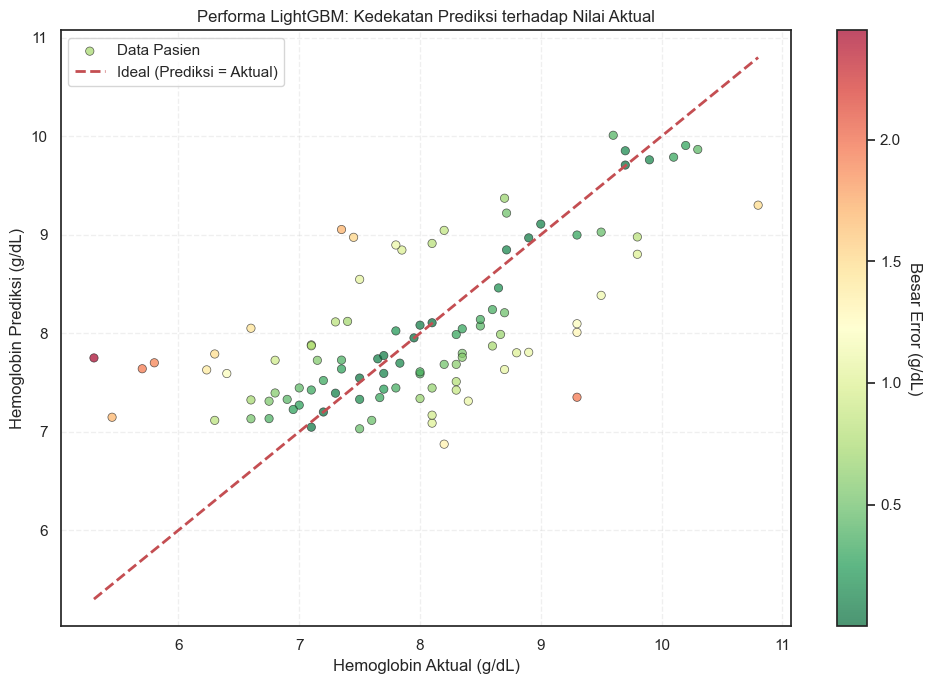

In [74]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = models_final["LightGBM"].predict(X_test)
error_abs = np.abs(y_test - y_pred)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(y_test, y_pred, 
                      c=error_abs, 
                      cmap='RdYlGn_r', 
                      alpha=0.7, 
                      edgecolors='k', 
                      linewidths=0.5,
                      label='Data Pasien')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Ideal (Prediksi = Aktual)')

cbar = plt.colorbar(scatter)
cbar.set_label('Besar Error (g/dL)', rotation=270, labelpad=15)

plt.xlabel("Hemoglobin Aktual (g/dL)")
plt.ylabel("Hemoglobin Prediksi (g/dL)")
plt.title("Performa LightGBM: Kedekatan Prediksi terhadap Nilai Aktual")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

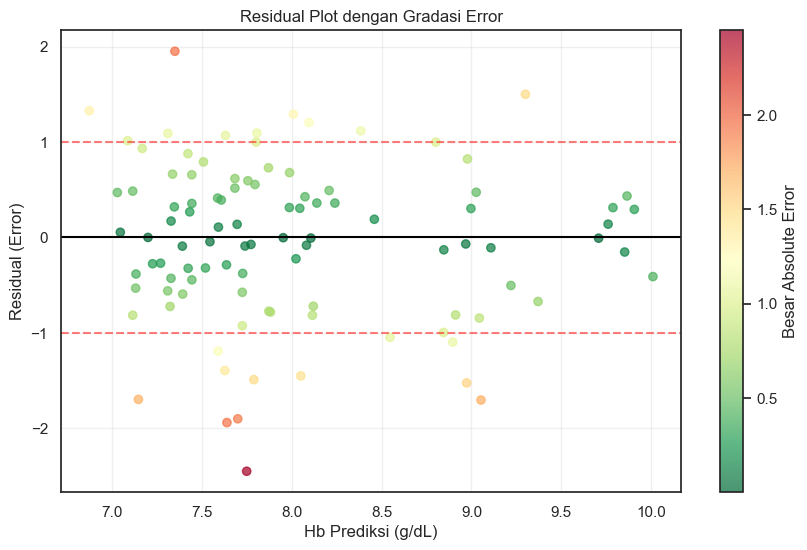

In [75]:
import numpy as np

# Hitung residual dan absolut error
residuals = y_test - y_pred
abs_error = np.abs(residuals)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(y_pred, residuals, c=abs_error, cmap='RdYlGn_r', alpha=0.7)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5) # Garis pusat
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)  # Batas error 1.0
plt.axhline(y=-1, color='red', linestyle='--', alpha=0.5) # Batas error -1.0

plt.colorbar(scatter, label='Besar Absolute Error')
plt.xlabel("Hb Prediksi (g/dL)")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot dengan Gradasi Error")
plt.grid(True, alpha=0.3)
plt.show()

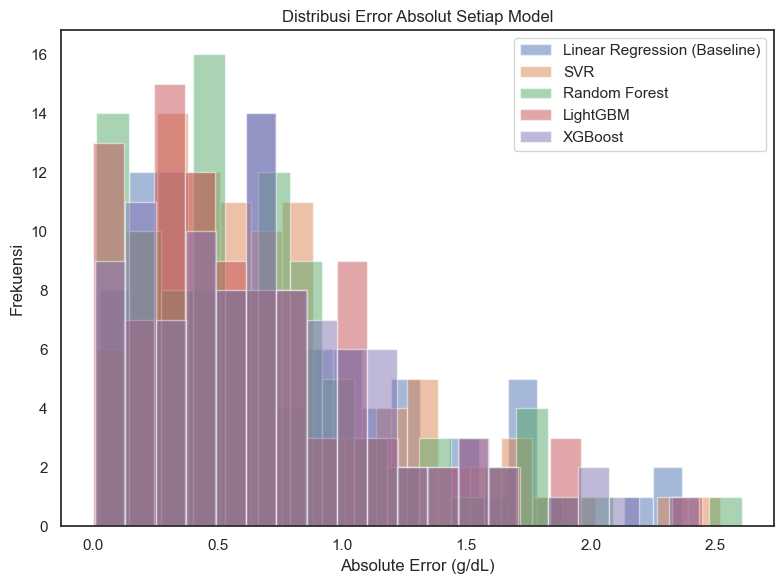

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models_final.items():
    y_pred = model.predict(X_test)
    abs_error = np.abs(y_test - y_pred)
    
    plt.hist(abs_error, bins=20, alpha=0.5, label=name)

plt.xlabel("Absolute Error (g/dL)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Error Absolut Setiap Model")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Windows\AppData\Local\Temp\ipykernel_2868\3502629487.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(errors, labels=models_final.keys(), showfliers=False)


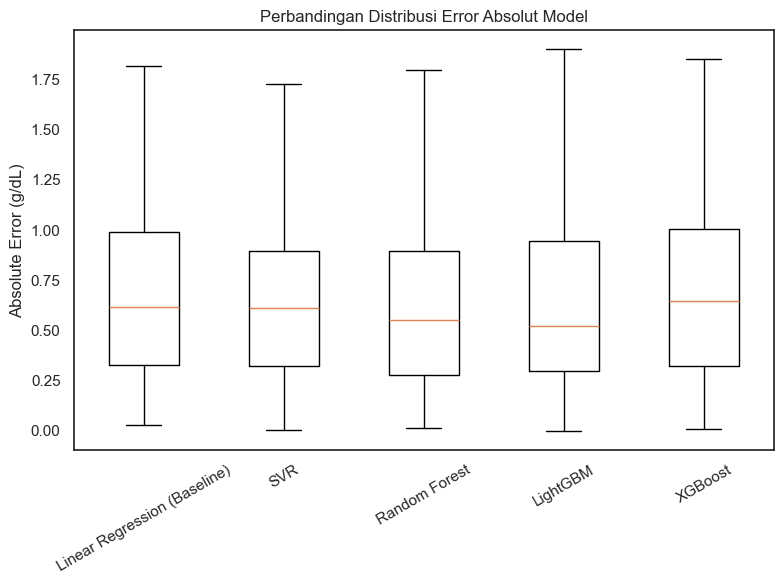

In [77]:
errors = []

for name, model in models_final.items():
    y_pred = model.predict(X_test)
    abs_error = np.abs(y_test - y_pred)
    errors.append(abs_error)

plt.figure(figsize=(8,6))
plt.boxplot(errors, labels=models_final.keys(), showfliers=False)
plt.ylabel("Absolute Error (g/dL)")
plt.title("Perbandingan Distribusi Error Absolut Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


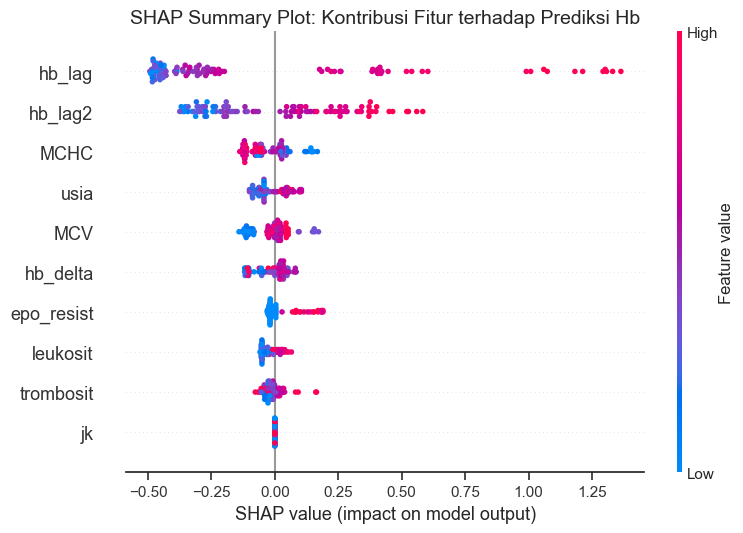

In [78]:
import shap
import matplotlib.pyplot as plt

best_lgbm = grid_lgbm.best_estimator_

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Kontribusi Fitur terhadap Prediksi Hb", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300)
plt.show()

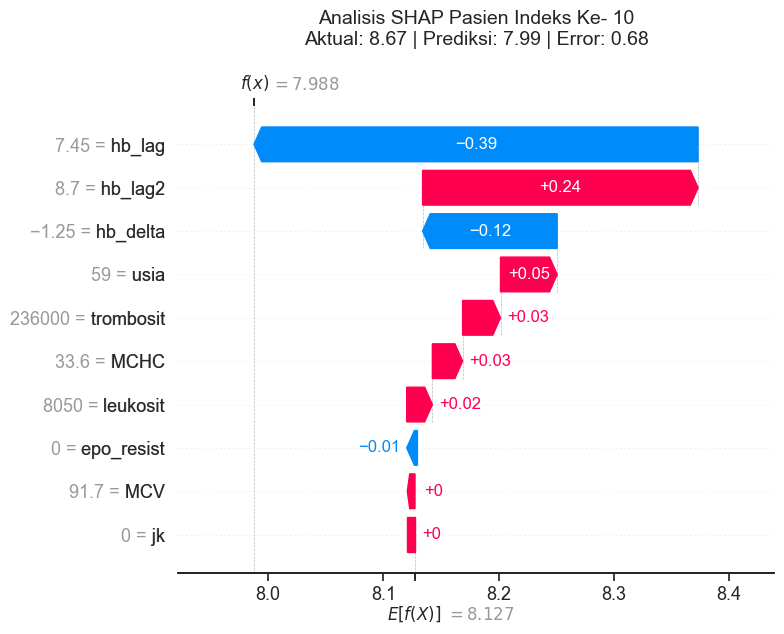

------------------------------
HASIL EVALUASI PASIEN KE- 10
------------------------------
Nilai Hb Aktual  : 8.67 g/dL
Hasil Prediksi   : 7.99 g/dL
Selisih (Error)  : 0.68 g/dL
Base Value (Avg) : 8.13 g/dL
------------------------------


In [79]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(grid_lgbm.best_estimator_)

# misal indeks 10
indeks_pasien = 10 
pasien_terpilih = X_test.iloc[[indeks_pasien]]

nilai_aktual = y_test.iloc[indeks_pasien]

prediksi = grid_lgbm.best_estimator_.predict(pasien_terpilih)[0]
error = abs(prediksi - nilai_aktual)

shap_values_pasien = explainer(pasien_terpilih)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_pasien[0], show=False)

plt.title(f"Analisis SHAP Pasien Indeks Ke- {indeks_pasien}\n"
          f"Aktual: {nilai_aktual:.2f} | Prediksi: {prediksi:.2f} | Error: {error:.2f}", 
          fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("-" * 30)
print(f"HASIL EVALUASI PASIEN KE- {indeks_pasien}")
print("-" * 30)
print(f"Nilai Hb Aktual  : {nilai_aktual:.2f} g/dL")
print(f"Hasil Prediksi   : {prediksi:.2f} g/dL")
print(f"Selisih (Error)  : {error:.2f} g/dL")
print(f"Base Value (Avg) : {explainer.expected_value:.2f} g/dL")
print("-" * 30)

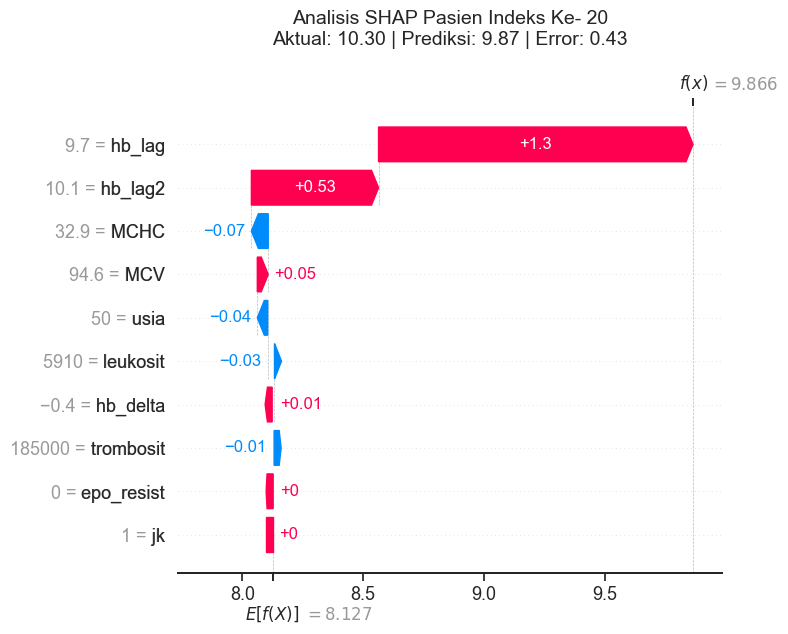

------------------------------
HASIL EVALUASI PASIEN KE- 20
------------------------------
Nilai Hb Aktual  : 10.30 g/dL
Hasil Prediksi   : 9.87 g/dL
Selisih (Error)  : 0.43 g/dL
Base Value (Avg) : 8.13 g/dL
------------------------------


In [80]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(grid_lgbm.best_estimator_)

# misal indeks 20
indeks_pasien = 20 
pasien_terpilih = X_test.iloc[[indeks_pasien]]

nilai_aktual = y_test.iloc[indeks_pasien]

prediksi = grid_lgbm.best_estimator_.predict(pasien_terpilih)[0]
error = abs(prediksi - nilai_aktual)

shap_values_pasien = explainer(pasien_terpilih)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_pasien[0], show=False)

plt.title(f"Analisis SHAP Pasien Indeks Ke- {indeks_pasien}\n"
          f"Aktual: {nilai_aktual:.2f} | Prediksi: {prediksi:.2f} | Error: {error:.2f}", 
          fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("-" * 30)
print(f"HASIL EVALUASI PASIEN KE- {indeks_pasien}")
print("-" * 30)
print(f"Nilai Hb Aktual  : {nilai_aktual:.2f} g/dL")
print(f"Hasil Prediksi   : {prediksi:.2f} g/dL")
print(f"Selisih (Error)  : {error:.2f} g/dL")
print(f"Base Value (Avg) : {explainer.expected_value:.2f} g/dL")
print("-" * 30)

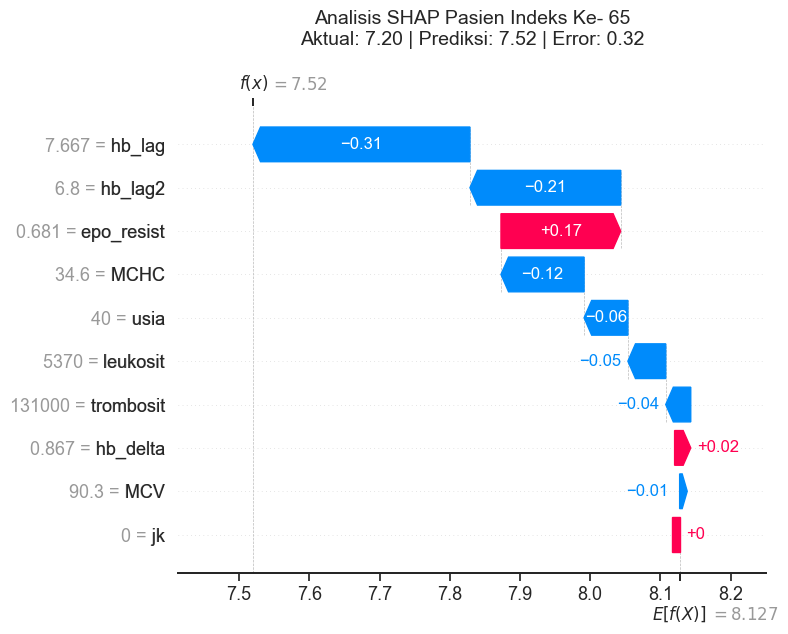

------------------------------
HASIL EVALUASI PASIEN KE- 65
------------------------------
Nilai Hb Aktual  : 7.20 g/dL
Hasil Prediksi   : 7.52 g/dL
Selisih (Error)  : 0.32 g/dL
Base Value (Avg) : 8.13 g/dL
------------------------------


In [81]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(grid_lgbm.best_estimator_)

# misal indeks 65
indeks_pasien = 65
pasien_terpilih = X_test.iloc[[indeks_pasien]]

nilai_aktual = y_test.iloc[indeks_pasien]

prediksi = grid_lgbm.best_estimator_.predict(pasien_terpilih)[0]
error = abs(prediksi - nilai_aktual)

shap_values_pasien = explainer(pasien_terpilih)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_pasien[0], show=False)

plt.title(f"Analisis SHAP Pasien Indeks Ke- {indeks_pasien}\n"
          f"Aktual: {nilai_aktual:.2f} | Prediksi: {prediksi:.2f} | Error: {error:.2f}", 
          fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("-" * 30)
print(f"HASIL EVALUASI PASIEN KE- {indeks_pasien}")
print("-" * 30)
print(f"Nilai Hb Aktual  : {nilai_aktual:.2f} g/dL")
print(f"Hasil Prediksi   : {prediksi:.2f} g/dL")
print(f"Selisih (Error)  : {error:.2f} g/dL")
print(f"Base Value (Avg) : {explainer.expected_value:.2f} g/dL")
print("-" * 30)

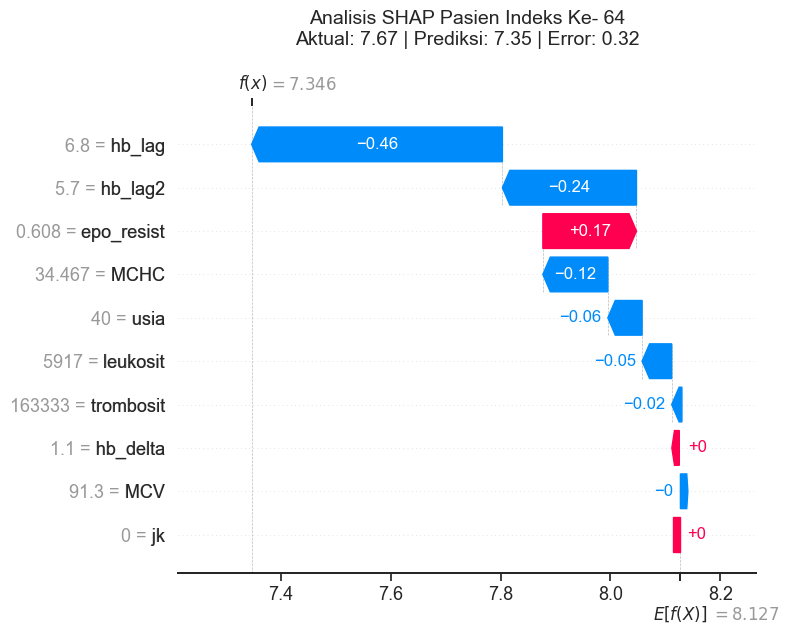

------------------------------
HASIL EVALUASI PASIEN KE- 64
------------------------------
Nilai Hb Aktual  : 7.67 g/dL
Hasil Prediksi   : 7.35 g/dL
Selisih (Error)  : 0.32 g/dL
Base Value (Avg) : 8.13 g/dL
------------------------------


In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(grid_lgbm.best_estimator_)

indeks_pasien = 64
pasien_terpilih = X_test.iloc[[indeks_pasien]]

nilai_aktual = y_test.iloc[indeks_pasien]

prediksi = grid_lgbm.best_estimator_.predict(pasien_terpilih)[0]
error = abs(prediksi - nilai_aktual)

shap_values_pasien = explainer(pasien_terpilih)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_pasien[0], show=False)

plt.title(f"Analisis SHAP Pasien Indeks Ke- {indeks_pasien}\n"
          f"Aktual: {nilai_aktual:.2f} | Prediksi: {prediksi:.2f} | Error: {error:.2f}", 
          fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("-" * 30)
print(f"HASIL EVALUASI PASIEN KE- {indeks_pasien}")
print("-" * 30)
print(f"Nilai Hb Aktual  : {nilai_aktual:.2f} g/dL")
print(f"Hasil Prediksi   : {prediksi:.2f} g/dL")
print(f"Selisih (Error)  : {error:.2f} g/dL")
print(f"Base Value (Avg) : {explainer.expected_value:.2f} g/dL")
print("-" * 30)